In [2]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [3]:
using Revise

In [5]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics

In [6]:
const de = DiffusionEvolution

DiffusionEvolution

In [17]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [7]:
d = 5
nsamples = 1000
T = 7

7

In [11]:
λ_diag = 1.0
λ_skew = 0.3
θ0 = [1.0, 0.0, 0.0, 0.0, 0.0]
θ1 = fill(1.0, d)
J, θ, min_eigv = random_pars(λ_diag, λ_skew, θ0, θ1, d=d);

In [12]:
min_eigv

0.6272583556232766

In [14]:
x = simulate_ou_process(J, θ, nsamples=nsamples, T=T);

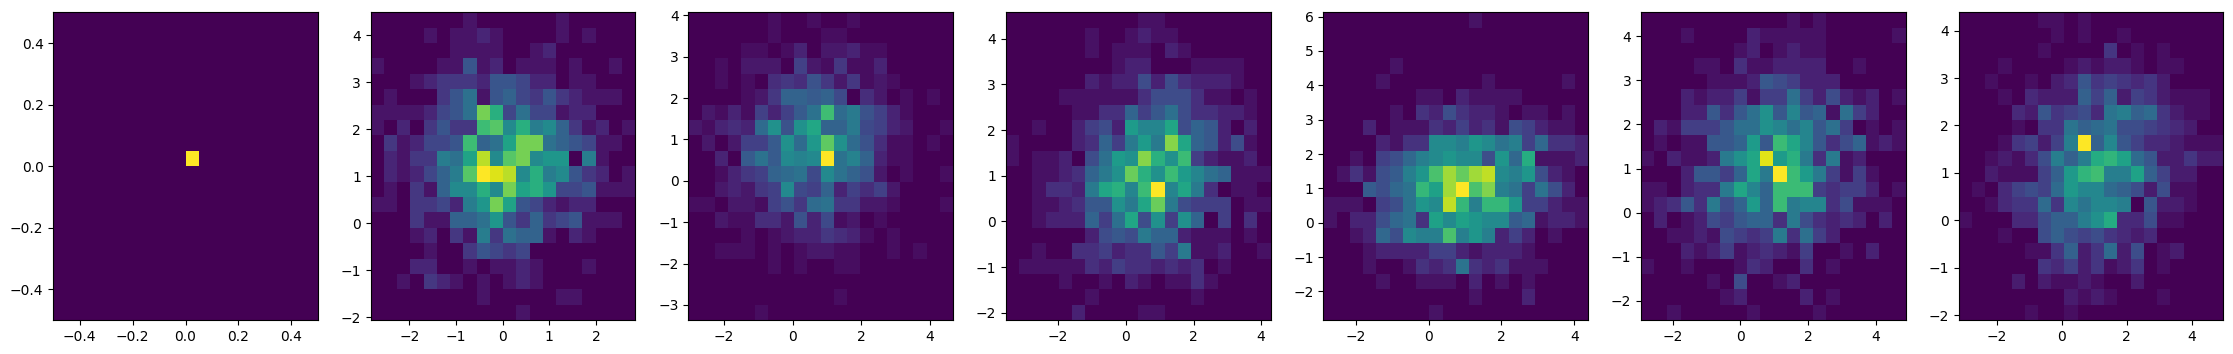

In [18]:
tpoints = 1:1:T
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
end

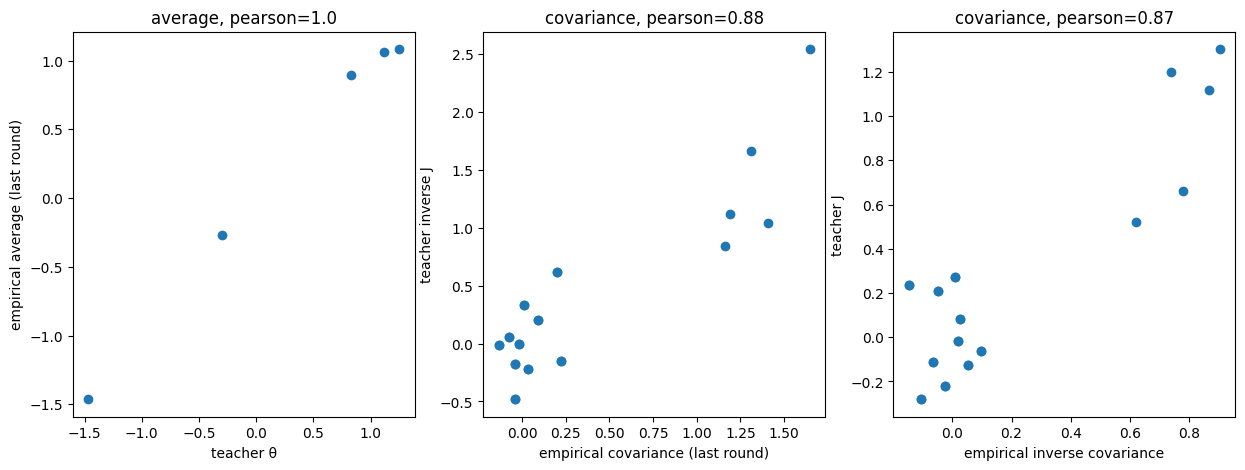

PyObject Text(0.5, 1.0, 'covariance, pearson=0.87')

In [48]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [31]:
counts = ones(nsamples, T) ./ nsamples
deltas = fill(1,T)
data = collect_data(x, counts, deltas);

In [32]:
l_values, x_opt = de.learn_gd(data, initialize=T, epochs=(10_000,), η=(0.001,), λ=0.0, verbose=true);

iter 1/10000: ll=6.52060328252323
iter 2/10000: ll=6.278636384420175
iter 3/10000: ll=6.048846193888197
iter 4/10000: ll=5.830720796876732
iter 5/10000: ll=5.623759710340832
iter 6/10000: ll=5.42747461272402
iter 7/10000: ll=5.241389968677199
iter 8/10000: ll=5.065043550704952
iter 9/10000: ll=4.8979868614966735
iter 10/10000: ll=4.739785461565897
iter 11/10000: ll=4.5900192074983295
iter 12/10000: ll=4.44828240661212
iter 13/10000: ll=4.314183894178243
iter 14/10000: ll=4.187347039552901
iter 15/10000: ll=4.0674096876538695
iter 16/10000: ll=3.9540240421872737
iter 17/10000: ll=3.846856496916463
iter 18/10000: ll=3.7455874210769737
iter 19/10000: ll=3.6499109047951706
iter 20/10000: ll=3.559534470077136
iter 21/10000: ll=3.474178752609981
iter 22/10000: ll=3.393577159271428
iter 23/10000: ll=3.317475505883546
iter 24/10000: ll=3.245631639381589
iter 25/10000: ll=3.177815048204389
iter 26/10000: ll=3.1138064643556946
iter 27/10000: ll=3.0533974602385676
iter 28/10000: ll=2.996390043032

In [ ]:
l_values, x_opt = de.learn_gd(data, initialize=-1, x0=x_opt,
    epochs=(500_000,), η=(0.001,), λ=0.0, verbose=false);

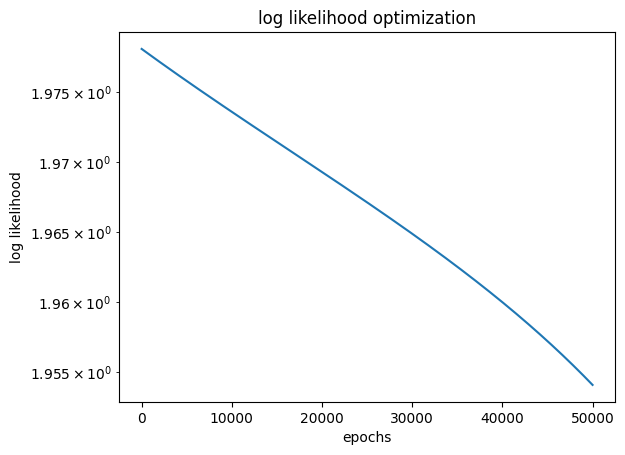

In [50]:
plot(l_values)
xlabel("epochs")
ylabel("log likelihood")
title("log likelihood optimization")
yscale(:log);

In [51]:
J_inferred = de.compute_J(x_opt, data.d);

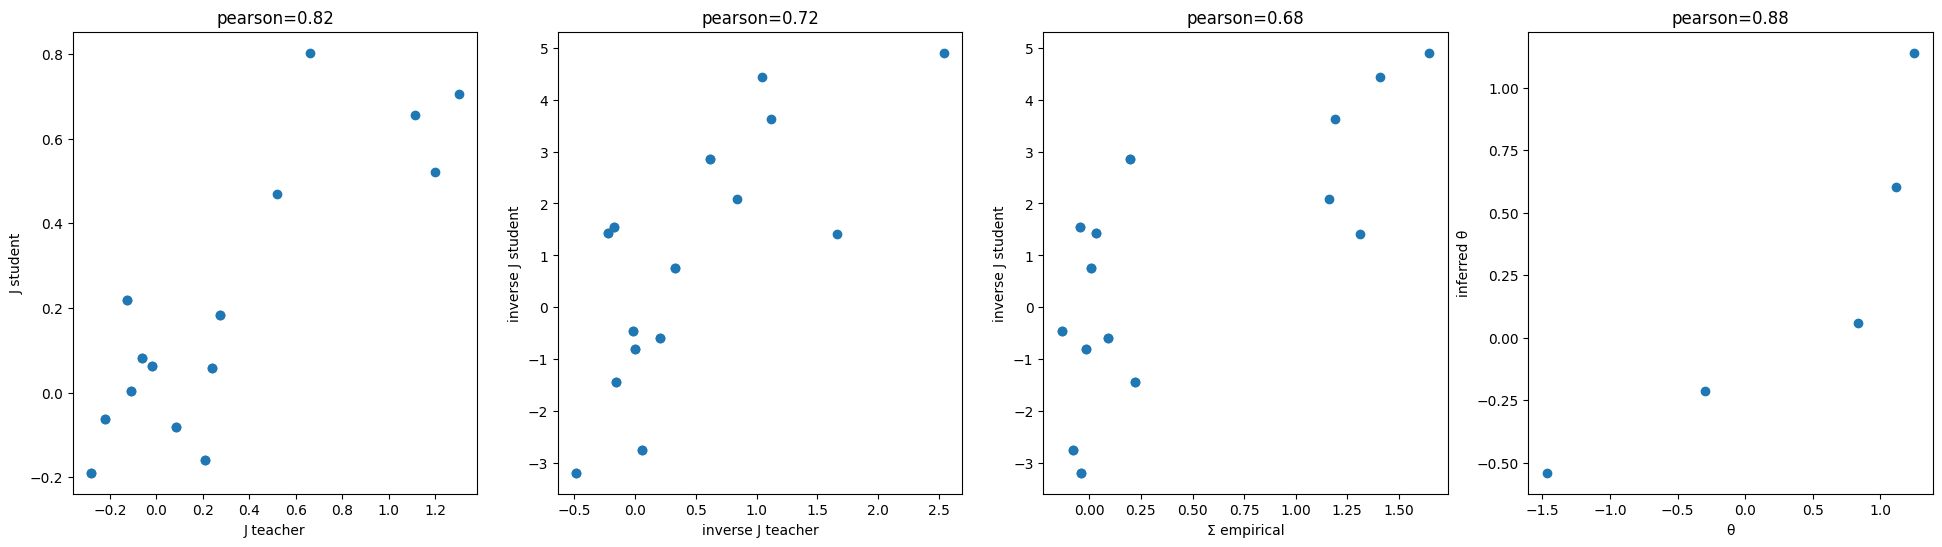

PyObject Text(0.5, 1.0, 'pearson=0.88')

In [52]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
rho_theta = cor(vec(θ), x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")